# Loans at Risk: Capturing Default - EXPLORATORY DATA ANALYSIS

## Objective
This notebook examines the feature space produced during the ETL stage in order to understand how borrower characteristics relate to loan default risk. The purpose is not simply to inspect variable distributions, but to evaluate whether the information available at the time a borrower submits a loan application contains meaningful signals for predicting repayment outcomes.

The analysis operates within the **application-submission prediction boundary** established earlier in the pipeline. Only information observable when the borrower applied for the loan is used for modeling. During ETL the dataset was organized into two layers. The **clean dataset** preserves the normalized loan records and retains additional variables that describe the full loan lifecycle. The **feature base dataset** contains the subset of variables that respect the application-time information boundary and therefore form the modeling feature space.

This separation allows diagnostic validation to use the full loan record while ensuring that predictive modeling relies only on information that would have been available at the moment of application. The analysis in this notebook therefore examines the structure of the dataset and evaluates whether the variables within the modeling boundary plausibly capture mechanisms relevant to credit risk.

---

## Analytical Structure
The analysis is organized in two stages corresponding to the dataset layers produced during the ETL notebook.

1. **Diagnostic validation using the clean dataset**  
2. **Decision-focused analysis using the feature base dataset**

The first stage verifies that the dataset behaves coherently from a lending perspective. Loan outcomes must follow a plausible repayment structure, the temporal ordering of the dataset must reflect the development of lending cohorts over time, and the modeling population must be clearly defined. Before any modeling work begins, the dataset itself must demonstrate that it represents a valid observation of the lending process.

The second stage examines the variables that remain within the modeling boundary and evaluates whether they contain meaningful signals for predicting loan default. The focus here is analytical rather than technical: the objective is to understand how borrower characteristics, loan terms, and credit behavior relate to repayment outcomes and whether those relationships appear stable enough to support modeling.

Taken together, these two stages move from **dataset integrity** to **risk signal investigation**, establishing both the validity of the data and the analytical basis for the modeling phase that follows.

---

## Notebook Structure

### Part 1 — Diagnostic Validation (`clean`)
The first stage evaluates the structural integrity of the dataset using the **clean training dataset** and **clean testing dataset**. The objective is to confirm that the outcome variable, temporal structure, and dataset composition behave as expected before any modeling analysis is performed.

Loan datasets contain a mixture of completed and ongoing repayment states. For modeling purposes the analysis must focus on outcomes that represent the completed repayment process. This stage therefore verifies that the loan status variable provides a coherent representation of repayment outcomes and that the modeling cohort can be defined in a way that reflects final borrower behavior.

In addition to validating outcome definitions, this stage examines the temporal structure of the dataset. Lending platforms evolve over time, loan volumes change across years, and reporting practices may shift. Confirming the temporal structure ensures that the modeling phase trains on earlier lending cohorts and evaluates performance on a later period.

This stage defines the modeling population by excluding loans whose repayment outcome has not yet been determined. Once the modeling cohort is established, the analysis proceeds to examine the submission-time features available at loan application.

### Part 2 — Decision EDA (`feature_base`)
The second stage analyzes the feature space used for modeling. The analysis focuses exclusively on variables contained in the **feature base training dataset** and **feature base testing dataset**, which include only information available at application submission.

To keep the analysis interpretable, variables are examined in groups that reflect the types of information available when a borrower applies for a loan:


1. **Target Definition & Cohort**
2. **Application Profile**
3. **Loan Structure**
4. **Debt Burden**
5. **Credit History**
6. **Recent Credit Behavior**
7. **Reporting Shifts / Data Quality**

These domains organize the variables according to the type of information they represent. Application profile variables describe the borrower’s financial situation at the moment of application. Loan structure variables describe the contractual terms of the loan itself. Debt burden measures the borrower’s leverage relative to income and available credit. Credit history and recent credit behavior summarize how the borrower has managed credit obligations in the past. Reporting shifts and data quality are examined separately to identify structural artifacts that could affect modeling.


In [1]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()
project_root = None

for parent_path in (current_path, *current_path.parents):
    if (parent_path / "pyproject.toml").exists():
        project_root = parent_path
        break

if project_root is None:
    raise RuntimeError(
        f"Failed to resolve project root: pyproject.toml not found from {current_path}"
    )

src_path = project_root / "src"
if not src_path.exists():
    raise RuntimeError(f"Expected 'src' directory at: {src_path}")

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

{
    "stage": "bootstrap_import_path_ready",
    "project_root": str(project_root),
}


{'stage': 'bootstrap_import_path_ready',
 'project_root': 'D:\\Portfolio\\loans-at-risk-capturing-default'}

In [2]:
# ============================================================================
# Imports: libraries and project modules
# ============================================================================

from datetime import datetime, timezone
from typing import Callable
import uuid

from IPython.display import display
import pandas as pd

import analysis.eda as eda
import plots.eda_figures as eda_fig
import config.logging as log_config



In [3]:
# ===============================
# Paths and run context
# ===============================

logs_root = project_root / "logs"
logs_root.mkdir(parents=True, exist_ok=True)

PROJECT_LOG_FILE = logs_root / "project.log"

run_id = uuid.uuid4().hex[:10]
run_timestamp_utc = datetime.now(timezone.utc)

run_header = (
    "NEW RUN: "
    f"{run_timestamp_utc.strftime('%Y-%m-%d %H:%M:%S')} UTC | "
    f"RUN_ID={run_id}"
)

log_config.log_messages("\n" + "=" * 60, PROJECT_LOG_FILE)
log_config.log_messages(run_header, PROJECT_LOG_FILE)
log_config.log_messages("=" * 60 + "\n", PROJECT_LOG_FILE)

log: Callable[[str], None] = log_config.get_logger(PROJECT_LOG_FILE)
log("EDA notebook initialized")
log(f"project_root: {project_root}")
log(run_header)

{
    "stage": "run_started",
    "run_id": run_id,
    "utc_timestamp": run_timestamp_utc.isoformat(),
}

# ---------------------------------------------------------------
# Inputs for this notebook (interim, report)
# ---------------------------------------------------------------

clean_train_data_file = project_root / "data" / "interim" / "clean_loan_data_2007_2014.parquet"
clean_test_data_file = project_root / "data" / "interim" / "clean_loan_data_2015.parquet"

feature_base_train_data_file = project_root / "data" / "interim" / "feature_base_loan_data_2007_2014.parquet"
feature_base_test_data_file = project_root / "data" / "interim" / "feature_base_loan_data_2015.parquet"

artifacts_dir = project_root / "artifacts"
eda_artifacts_dir = artifacts_dir / "eda"
eda_tables_dir = eda_artifacts_dir / "tables"
eda_figures_dir = eda_artifacts_dir / "figures"

eda_tables_dir.mkdir(parents=True, exist_ok=True)
eda_figures_dir.mkdir(parents=True, exist_ok=True)

log(f"Clean train parquet path: {clean_train_data_file}")
log(f"Clean test parquet path: {clean_test_data_file}")
log(f"Feature base train parquet path: {feature_base_train_data_file}")
log(f"Feature base test parquet path: {feature_base_test_data_file}")
log(f"EDA tables directory: {eda_tables_dir}")
log(f"EDA figures directory: {eda_figures_dir}")


## Part 1 — Diagnostic Validation (`clean`)

This section evaluates outcome integrity, cohort definition, temporal structure, and reporting stability using the **clean training dataset** and **clean testing dataset**. The objective is to confirm that the outcome variable, temporal structure, and dataset composition behave coherently before any feature-level analysis begins.

The clean dataset retains the full loan record. That makes it the correct layer for validating repayment outcomes, defining the realized-outcome modeling cohort, and examining temporal diagnostics based on `issue_d`.


#### Dataset Overview

In [4]:
# --------------------------------------------------------
# Load clean datasets + checkpoint
# --------------------------------------------------------

df_clean_train = pd.read_parquet(clean_train_data_file)
df_clean_test = pd.read_parquet(clean_test_data_file)

clean_overview_df = eda.build_dataset_overview(
    df_train=df_clean_train,
    df_test=df_clean_test,
)

display(clean_overview_df)
log(f"[clean] overview: {clean_overview_df.to_dict(orient='records')}")


,dataset_split,rows,columns,memory_mb
0,train,466285,51,146.75
1,test,421094,51,132.52


In [5]:
# --------------------------------------------------------
# Add issue_year for temporal diagnostics
# --------------------------------------------------------

df_clean_train = eda.add_issue_year(
    df=df_clean_train,
    log=log,
)

df_clean_test = eda.add_issue_year(
    df=df_clean_test,
    log=log,
)

clean_year_summary_df = pd.DataFrame(
    [
        {
            "dataset_split": "train",
            "min_issue_year": int(df_clean_train["issue_year"].min()),
            "max_issue_year": int(df_clean_train["issue_year"].max()),
            "distinct_issue_years": int(df_clean_train["issue_year"].nunique()),
        },
        {
            "dataset_split": "test",
            "min_issue_year": int(df_clean_test["issue_year"].min()),
            "max_issue_year": int(df_clean_test["issue_year"].max()),
            "distinct_issue_years": int(df_clean_test["issue_year"].nunique()),
        },
    ]
)

display(clean_year_summary_df)
log(f"[clean][issue_year] summary: {clean_year_summary_df.to_dict(orient='records')}")


,dataset_split,min_issue_year,max_issue_year,distinct_issue_years
0,train,2007,2014,8
1,test,2015,2015,1


#### Outcome distribution by vintage

The table is more useful here than a stacked bar chart. The question is not visual composition for its own sake. The question is whether outcome composition shifts across issuance years in a way that affects cohort definition and label maturity.

Early vintages are dominated by realized repayment outcomes. Later periods contain a larger share of loans whose repayment process had not yet concluded at the moment of extraction. That difference must be handled before modeling.


In [6]:
# --------------------------------------------------------
# Outcome distribution by issue year
# --------------------------------------------------------

loan_status_by_year_train_df = eda.build_loan_status_by_issue_year_table(
    df=df_clean_train,
)

loan_status_by_year_test_df = eda.build_loan_status_by_issue_year_table(
    df=df_clean_test,
)

loan_status_by_year_combined_df = eda.build_split_table(
    df_train=loan_status_by_year_train_df,
    df_test=loan_status_by_year_test_df,
    index_name="issue_year",
)

display(loan_status_by_year_combined_df)

loan_status_by_year_artifact_file = eda_tables_dir / "clean_loan_status_by_issue_year.csv"
loan_status_by_year_combined_df.to_csv(loan_status_by_year_artifact_file)

{
    "stage": "clean_loan_status_by_issue_year_saved",
    "path": str(loan_status_by_year_artifact_file),
    "rows": int(loan_status_by_year_combined_df.shape[0]),
}


loan_status               charged_off  current  default  \
dataset_split issue_year                                  
train         2007                 45        0        0   
              2008                247        0        0   
              2009                594        0        0   
              2010               1483        7        1   
              2011               3205     1953        8   
              2012               8084     3444       28   
              2013              14836    60264      182   
              2014              13981   158558      613   
test          2015               2773   377553      387   

loan_status               does_not_meet_the_credit_policy._status:charged_off  \
dataset_split issue_year                                                        
train         2007                                                      113     
              2008                                                      249     
              2009                                                      129     
              2010                                                      270     
              2011                                                        0     
              2012                                                        0     
              2013                                                        0     
              2014                                                        0     
test          2015                                                        0     

loan_status               does_not_meet_the_credit_policy._status:fully_paid  \
dataset_split issue_year                                                       
train         2007                                                      239    
              2008                                                      582    
              2009                                                      436    
              2010                                                      731    
              2011                                                        0    
              2012                                                        0    
              2013                                                        0    
              2014                                                        0    
test          2015                                                        0    

loan_status               fully_paid  in_grace_period  issued  \
dataset_split issue_year                                        
train         2007               206                0       0   
              2008              1315                0       0   
              2009              4122                0       0   
              2010             10038                0       0   
              2011             16470               28       0   
              2012             41479               83       0   
              2013             56396              977       0   
              2014             54713             2058       0   
test          2015             22984             3107    8460   

loan_status               late_(16-30_days)  late_(31-120_days)  
dataset_split issue_year                                         
train         2007                        0                   0  
              2008                        0                   0  
              2009                        0                   0  
              2010                        2                   5  
              2011                       11                  46  
              2012                       27                 222  
              2013                      320                1780  
              2014                      858                4847  
test          2015                     1139                4691

{'stage': 'clean_loan_status_by_issue_year_saved',
 'path': 'D:\\Portfolio\\loans-at-risk-capturing-default\\artifacts\\eda\\tables\\clean_loan_status_by_issue_year.csv',
 'rows': 9}

#### Realized-outcome cohort definition

The modeling population is defined by excluding loans whose repayment outcome has not yet been determined. This removes censoring from the label and restricts the analysis to loans where borrower behavior is fully observed.

The resulting cohort is the relevant base for both later feature analysis and downstream modeling.


In [7]:
# --------------------------------------------------------
# Realized-outcome cohort definition
# --------------------------------------------------------

terminal_statuses_final = [
    "fully_paid",
    "charged_off",
    "default",
]

positive_statuses = [
    "charged_off",
    "default",
]

df_clean_train_terminal = eda.build_terminal_cohort(
    df=df_clean_train,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log=log,
)

df_clean_test_terminal = eda.build_terminal_cohort(
    df=df_clean_test,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log=log,
)

clean_terminal_summary_df = eda.build_terminal_cohort_summary(
    df_train=df_clean_train_terminal,
    df_test=df_clean_test_terminal,
)

display(clean_terminal_summary_df)
log(f"[clean][terminal_cohort] summary: {clean_terminal_summary_df.to_dict(orient='records')}")


,dataset_split,rows,columns,default_rate_percent,positive_count,negative_count,status_count_fully_paid,status_count_charged_off,status_count_default
0,train,228046,53,18.99,43307,184739,184739,42475,832
1,test,26144,53,12.09,3160,22984,22984,2773,387


#### Temporal Outcome Dynamics

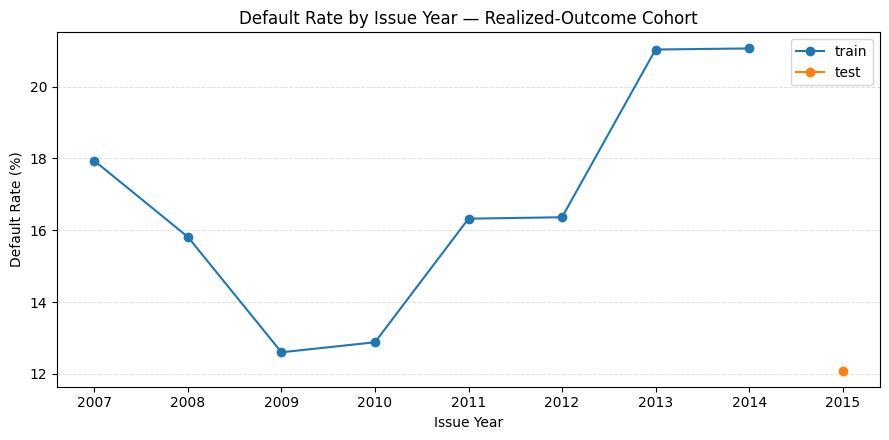

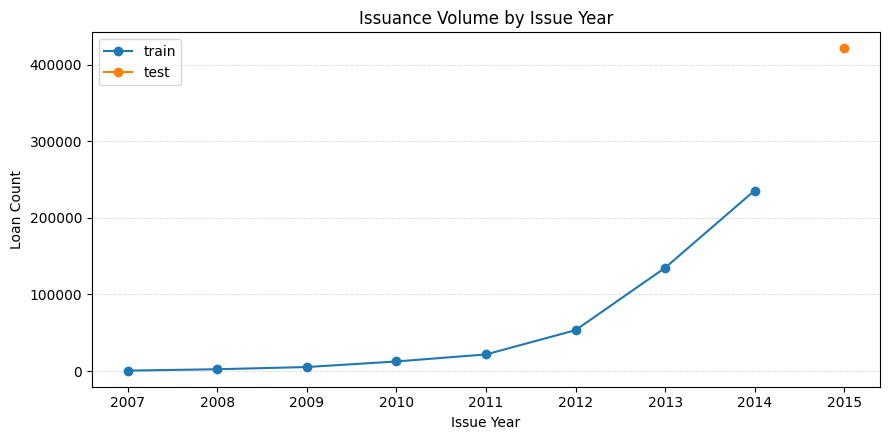

{'default_rate_by_issue_year_file': 'D:\\Portfolio\\loans-at-risk-capturing-default\\artifacts\\eda\\tables\\clean_default_rate_by_issue_year.csv',
 'issuance_volume_by_issue_year_file': 'D:\\Portfolio\\loans-at-risk-capturing-default\\artifacts\\eda\\tables\\clean_issuance_volume_by_issue_year.csv'}

In [8]:
# --------------------------------------------------------
# Temporal outcome dynamics
# --------------------------------------------------------

default_rate_by_year_train_df = eda.build_default_rate_by_issue_year(
    df=df_clean_train_terminal,
    dataset_split="train",
)

default_rate_by_year_test_df = eda.build_default_rate_by_issue_year(
    df=df_clean_test_terminal,
    dataset_split="test",
)

default_rate_by_year_df = pd.concat(
    [default_rate_by_year_train_df, default_rate_by_year_test_df],
    axis=0,
    ignore_index=True,
)

issuance_volume_by_year_train_df = eda.build_issuance_volume_by_issue_year(
    df=df_clean_train,
    dataset_split="train",
)

issuance_volume_by_year_test_df = eda.build_issuance_volume_by_issue_year(
    df=df_clean_test,
    dataset_split="test",
)

issuance_volume_by_year_df = pd.concat(
    [issuance_volume_by_year_train_df, issuance_volume_by_year_test_df],
    axis=0,
    ignore_index=True,
)


eda_fig.plot_line_comparison(
    default_rate_by_year_df,
    x_column="issue_year",
    y_column="default_rate_percent",
    split_column="dataset_split",
    title="Default Rate by Issue Year — Realized-Outcome Cohort",
    xlabel="Issue Year",
    ylabel="Default Rate (%)",
)

eda_fig.plot_line_comparison(
    issuance_volume_by_year_df,
    x_column="issue_year",
    y_column="loan_count",
    split_column="dataset_split",
    title="Issuance Volume by Issue Year",
    xlabel="Issue Year",
    ylabel="Loan Count",
)

default_rate_by_year_file = eda_tables_dir / "clean_default_rate_by_issue_year.csv"
default_rate_by_year_df.to_csv(default_rate_by_year_file, index=False)

issuance_volume_by_year_file = eda_tables_dir / "clean_issuance_volume_by_issue_year.csv"
issuance_volume_by_year_df.to_csv(issuance_volume_by_year_file, index=False)

{
    "default_rate_by_issue_year_file": str(default_rate_by_year_file),
    "issuance_volume_by_issue_year_file": str(issuance_volume_by_year_file),
}


#### Reporting Stability by Vintage

,dataset_split,feature_name,min_missing_percent,max_missing_percent
0,train,tot_coll_amt,0.0,100.0
1,train,tot_cur_bal,0.0,100.0
2,train,total_rev_hi_lim,0.0,100.0
3,test,tot_coll_amt,0.0,0.0
4,test,tot_cur_bal,0.0,0.0
5,test,total_rev_hi_lim,0.0,0.0


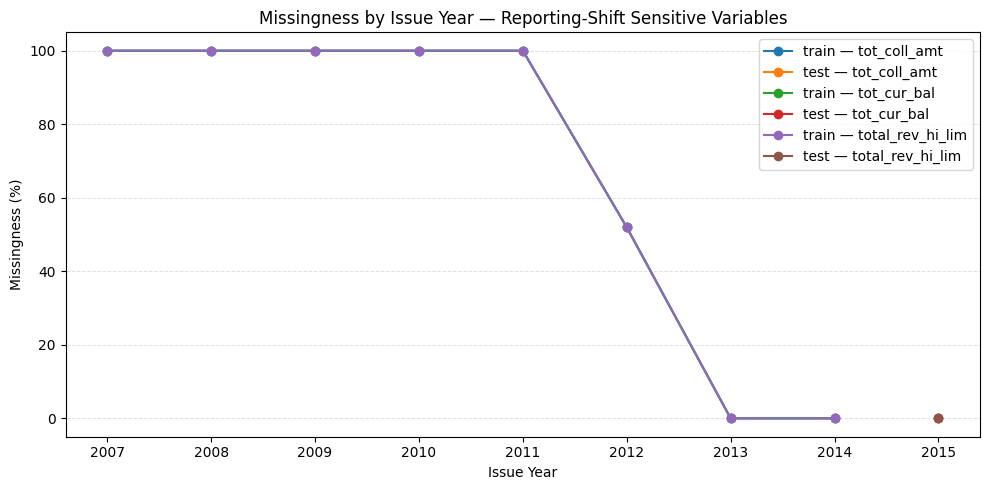

In [9]:
# --------------------------------------------------------
# Reporting stability assessment
# --------------------------------------------------------

reporting_shift_columns = [
    "tot_coll_amt",
    "tot_cur_bal",
    "total_rev_hi_lim",
]

missingness_by_year_train_df = eda.build_missingness_by_issue_year(
    df=df_clean_train,
    column_names=reporting_shift_columns,
    dataset_split="train",
)

missingness_by_year_test_df = eda.build_missingness_by_issue_year(
    df=df_clean_test,
    column_names=reporting_shift_columns,
    dataset_split="test",
)

missingness_by_year_df = pd.concat(
    [missingness_by_year_train_df, missingness_by_year_test_df],
    axis=0,
    ignore_index=True,
)

reporting_shift_summary_df = (
    missingness_by_year_df
    .groupby(["dataset_split", "feature_name"], as_index=False)
    .agg(
        min_missing_percent=("missing_percent", "min"),
        max_missing_percent=("missing_percent", "max"),
    )
)

reporting_shift_summary_df["dataset_split"] = pd.Categorical(
    reporting_shift_summary_df["dataset_split"],
    categories=["train", "test"],
    ordered=True,
)

reporting_shift_summary_df = reporting_shift_summary_df.sort_values(
    ["dataset_split", "feature_name"]
).reset_index(drop=True)

display(reporting_shift_summary_df)

reporting_shift_series_order = [
    f"{dataset_split} — {feature_name}"
    for feature_name in reporting_shift_columns
    for dataset_split in ["train", "test"]
]

eda_fig.plot_multi_series_line_chart(
    missingness_by_year_df,
    x_column="issue_year",
    y_column="missing_percent",
    series_column="series_label",
    series_order=reporting_shift_series_order,
    title="Missingness by Issue Year — Reporting-Shift Sensitive Variables",
    xlabel="Issue Year",
    ylabel="Missingness (%)",
)

reporting_shift_file = eda_tables_dir / "clean_reporting_shift_summary.csv"
reporting_shift_summary_df.to_csv(reporting_shift_file, index=False)

log(f"[clean][reporting_shift] rows={missingness_by_year_df.shape[0]}")

#### Structural Boundary Confirmation

total_pymnt  total_rec_prncp  recoveries  out_prncp
dataset_split loan_status                                                     
train         charged_off      6657.34          3484.71      926.52       0.00
              default          7782.17          4755.83        0.00   10529.06
              fully_paid      15209.87         13158.29        0.00       0.00
test          charged_off      1962.42           900.98      343.69       0.00
              default          2004.71          1111.51        0.00   13886.62
              fully_paid      15000.28         14293.82        0.00       0.00

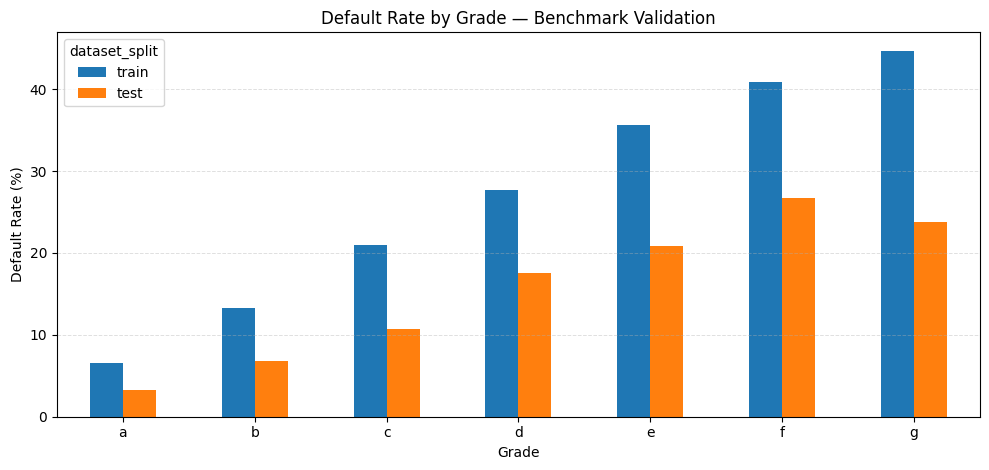

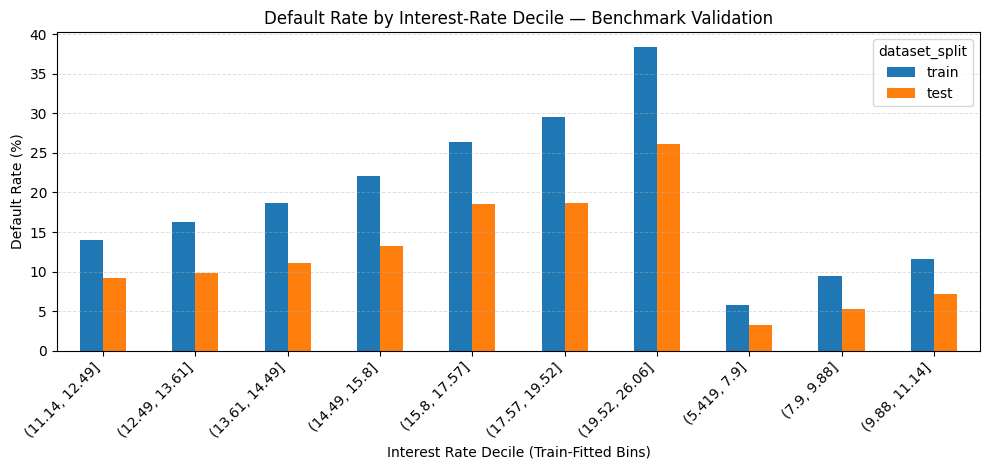

In [10]:
# --------------------------------------------------------
# Structural boundary confirmation
# --------------------------------------------------------

benchmark_cashflow_columns = [
    "total_pymnt",
    "total_rec_prncp",
    "recoveries",
    "out_prncp",
]

cashflow_coherence_train_df = eda.build_group_mean_table(
    df=df_clean_train_terminal,
    group_column="loan_status",
    value_columns=benchmark_cashflow_columns,
)

cashflow_coherence_test_df = eda.build_group_mean_table(
    df=df_clean_test_terminal,
    group_column="loan_status",
    value_columns=benchmark_cashflow_columns,
)

cashflow_coherence_combined_df = eda.build_split_table(
    df_train=cashflow_coherence_train_df,
    df_test=cashflow_coherence_test_df,
    index_name="loan_status",
)

display(cashflow_coherence_combined_df)

default_rate_by_grade_df = eda.build_default_rate_by_category_comparison(
    df_train=df_clean_train_terminal,
    df_test=df_clean_test_terminal,
    feature_name="grade",
)

eda_fig.plot_default_rate_comparison(
    default_rate_by_grade_df,
    category_column="grade",
    title="Default Rate by Grade — Benchmark Validation",
    xlabel="Grade",
)

int_rate_decile_df = eda.build_default_rate_by_train_fitted_quantile(
    df_train=df_clean_train_terminal,
    df_test=df_clean_test_terminal,
    feature_name="int_rate",
    number_of_bins=10,
)

eda_fig.plot_default_rate_comparison(
    int_rate_decile_df,
    category_column="feature_bin",
    title="Default Rate by Interest-Rate Decile — Benchmark Validation",
    xlabel="Interest Rate Decile (Train-Fitted Bins)",
    rotate_labels=True,
)

benchmark_validation_file = eda_tables_dir / "clean_benchmark_validation.csv"
pd.concat(
    [
        default_rate_by_grade_df.rename(columns={"grade": "feature_bin"}),
        int_rate_decile_df,
    ],
    axis=0,
    ignore_index=True,
).to_csv(benchmark_validation_file, index=False)

benchmark_validation_artifact_metadata = {
    "benchmark_validation_file": str(benchmark_validation_file),
}


#### 1.6 Diagnostic summary

The clean dataset confirms three things. First, the outcome variable behaves coherently once non-realized repayment states are excluded. Second, the temporal structure of the dataset supports the train-then-test evaluation design. Third, reporting shifts are visible in a small set of balance variables and must be treated as data-quality issues rather than borrower behavior.

With the realized-outcome cohort established, the analysis can move to the submission-time feature space used for modeling.


## Part 2 — Decision-Focused Analysis (`feature_base`)

This section analyzes the submission-time feature space used for modeling. The **feature base training dataset** and **feature base testing dataset** contain only variables that satisfy the application-submission prediction boundary.

The feature base dataset does **not** retain `issue_d`. Temporal diagnostics therefore stop here. From this point onward the analysis is strictly cross-sectional: borrower profile, contract terms, balance-sheet burden, credit history, recent credit behavior, and reporting-shift-sensitive fields are evaluated only through information available at application.


#### Feature-Base Dataset Overview

In [11]:
# --------------------------------------------------------
# Load feature base datasets + checkpoint
# --------------------------------------------------------

df_feature_base_train = pd.read_parquet(feature_base_train_data_file)
df_feature_base_test = pd.read_parquet(feature_base_test_data_file)

feature_base_overview_df = eda.build_dataset_overview(
    df_train=df_feature_base_train,
    df_test=df_feature_base_test,
)

display(feature_base_overview_df)
log(f"[feature_base] overview: {feature_base_overview_df.to_dict(orient='records')}")


,dataset_split,rows,columns,memory_mb
0,train,466285,27,73.82
1,test,421094,27,66.66


#### Realized-Outcome Cohort in Feature Base

In [12]:
# --------------------------------------------------------
# Build terminal cohort for feature-space analysis
# --------------------------------------------------------

df_feature_base_train_terminal = eda.build_terminal_cohort(
    df=df_feature_base_train,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log=log,
)

df_feature_base_test_terminal = eda.build_terminal_cohort(
    df=df_feature_base_test,
    status_column="loan_status",
    terminal_statuses=terminal_statuses_final,
    positive_statuses=positive_statuses,
    target_column="target_default",
    log=log,
)

feature_base_terminal_summary_df = eda.build_terminal_cohort_summary(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
)

display(feature_base_terminal_summary_df)
log(f"[feature_base][terminal_cohort] summary: {feature_base_terminal_summary_df.to_dict(orient='records')}")


,dataset_split,rows,columns,default_rate_percent,positive_count,negative_count,status_count_fully_paid,status_count_charged_off,status_count_default
0,train,228046,28,18.99,43307,184739,184739,42475,832
1,test,26144,28,12.09,3160,22984,22984,2773,387


#### Feature Group Coverage Audit

In [13]:
# --------------------------------------------------------
# Feature groups and coverage audit
# --------------------------------------------------------

feature_groups = {
    "target_definition_and_cohort": [
        "loan_status",
        "target_default",
    ],
    "application_profile": [
        "annual_inc",
        "home_ownership",
        "emp_length_years",
    ],
    "loan_structure": [
        "loan_amnt",
        "term_months",
        "purpose",
    ],
    "debt_burden": [
        "dti",
        "revol_util",
        "revol_bal",
        "tot_cur_bal",
        "tot_coll_amt",
        "total_rev_hi_lim",
    ],
    "credit_history": [
        "earliest_cr_line",
        "open_acc",
        "total_acc",
        "delinq_2yrs",
        "pub_rec",
        "collections_12_mths_ex_med",
        "acc_now_delinq",
    ],
    "recent_credit_behavior": [
        "inq_last_6mths",
        "mths_since_last_delinq",
        "mths_since_last_major_derog",
        "mths_since_last_record",
        "has_mths_since_last_delinq",
        "has_mths_since_last_major_derog",
        "has_mths_since_last_record",
    ],
    "reporting_shifts_data_quality": [
        "tot_coll_amt_missing",
        "tot_cur_bal_missing",
        "total_rev_hi_lim_missing",
    ],
}

feature_group_audit_train = eda.build_feature_group_audit(
    df=df_feature_base_train_terminal,
    feature_groups=feature_groups,
)

feature_group_audit_test = eda.build_feature_group_audit(
    df=df_feature_base_test_terminal,
    feature_groups=feature_groups,
)

feature_group_coverage_summary_df = pd.concat(
    [
        feature_group_audit_train["coverage_summary"].assign(dataset_split="train"),
        feature_group_audit_test["coverage_summary"].assign(dataset_split="test"),
    ],
    axis=0,
    ignore_index=True,
)

feature_group_coverage_summary_df = feature_group_coverage_summary_df[
    [
        "dataset_split",
        "feature_group",
        "grouped_feature_count",
        "present_feature_count",
        "missing_feature_count",
    ]
]

feature_group_coverage_summary_df["dataset_split"] = pd.Categorical(
    feature_group_coverage_summary_df["dataset_split"],
    categories=["train", "test"],
    ordered=True,
)

feature_group_coverage_summary_df = feature_group_coverage_summary_df.sort_values(
    ["dataset_split", "feature_group"]
).reset_index(drop=True)

display(feature_group_coverage_summary_df)

feature_group_audit_file = eda_tables_dir / "feature_group_audit.csv"
pd.concat(
    [
        feature_group_audit_train["coverage_summary"].assign(
            dataset_split="train",
            table_name="coverage_summary",
        ),
        feature_group_audit_test["coverage_summary"].assign(
            dataset_split="test",
            table_name="coverage_summary",
        ),
        feature_group_audit_train["feature_group_summary"].assign(
            dataset_split="train",
            table_name="feature_group_summary",
        ),
        feature_group_audit_test["feature_group_summary"].assign(
            dataset_split="test",
            table_name="feature_group_summary",
        ),
    ],
    axis=0,
    ignore_index=True,
).to_csv(feature_group_audit_file, index=False)

log(
    "[feature_base][feature_group_audit] "
    f"train_duplicate_grouped_columns={len(feature_group_audit_train['duplicate_grouped_columns'])} | "
    f"test_duplicate_grouped_columns={len(feature_group_audit_test['duplicate_grouped_columns'])} | "
    f"train_ungrouped_columns_count={len(feature_group_audit_train['ungrouped_columns'])} | "
    f"test_ungrouped_columns_count={len(feature_group_audit_test['ungrouped_columns'])}"
)


,dataset_split,feature_group,grouped_feature_count,present_feature_count,missing_feature_count
0,train,application_profile,3,3,0
1,train,credit_history,7,6,1
2,train,debt_burden,6,6,0
3,train,loan_structure,3,3,0
4,train,recent_credit_behavior,7,7,0
5,train,reporting_shifts_data_quality,3,0,3
6,train,target_definition_and_cohort,2,2,0
7,test,application_profile,3,3,0
8,test,credit_history,7,6,1
9,test,debt_burden,6,6,0


### 2.1 Target Definition & Cohort

The feature base dataset uses the same realized-outcome restriction as the clean dataset. This keeps the label definition consistent while limiting the analysis to variables that were available at application submission.

At this stage the relevant question is not temporal drift by issuance date. The relevant question is whether the submission-time feature space is examined on the same realized-outcome population defined earlier.


In [14]:
# --------------------------------------------------------
# Target behavior inside feature_base
# --------------------------------------------------------

baseline_default_rate_df = feature_base_terminal_summary_df[
    ["dataset_split", "rows", "default_rate_percent", "positive_count", "negative_count"]
].copy()

display(baseline_default_rate_df)

feature_base_target_summary_file = eda_tables_dir / "feature_base_target_summary.csv"
baseline_default_rate_df.to_csv(feature_base_target_summary_file, index=False)

feature_base_target_summary_artifact_metadata = {
    "feature_base_target_summary_file": str(feature_base_target_summary_file),
    "target_column_present_in_train": "target_default" in df_feature_base_train_terminal.columns,
    "target_column_present_in_test": "target_default" in df_feature_base_test_terminal.columns,
}


,dataset_split,rows,default_rate_percent,positive_count,negative_count
0,train,228046,18.99,43307,184739
1,test,26144,12.09,3160,22984


### 2.2 Application Profile

Application-profile variables describe the borrower at the moment of application. The relevant question is whether these fields separate repayment risk in a way that is both economically interpretable and stable across splits.


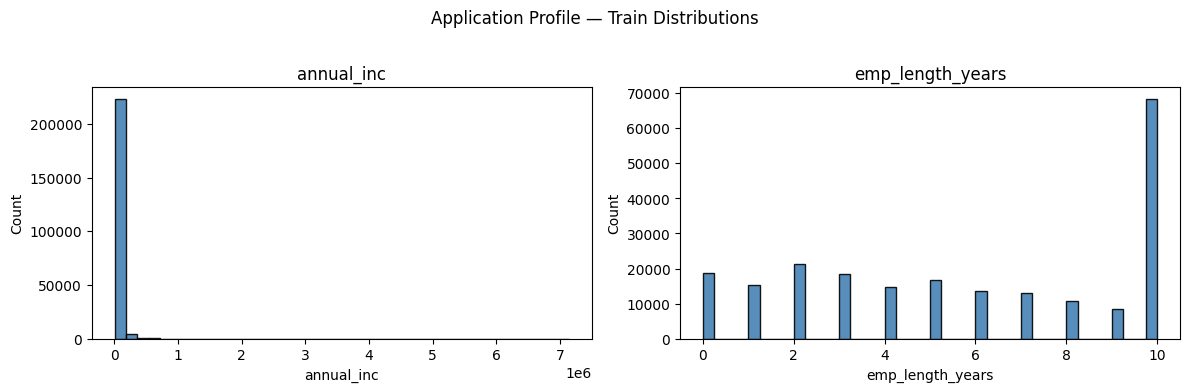

,feature_name,dataset_split,count,missing_percent,mean,median,p05,p95
0,annual_inc,train,228046,0.0,72011.35,62000.0,27600.0,145000.0
1,annual_inc,test,26144,0.0,76864.52,65000.0,30000.0,155000.0


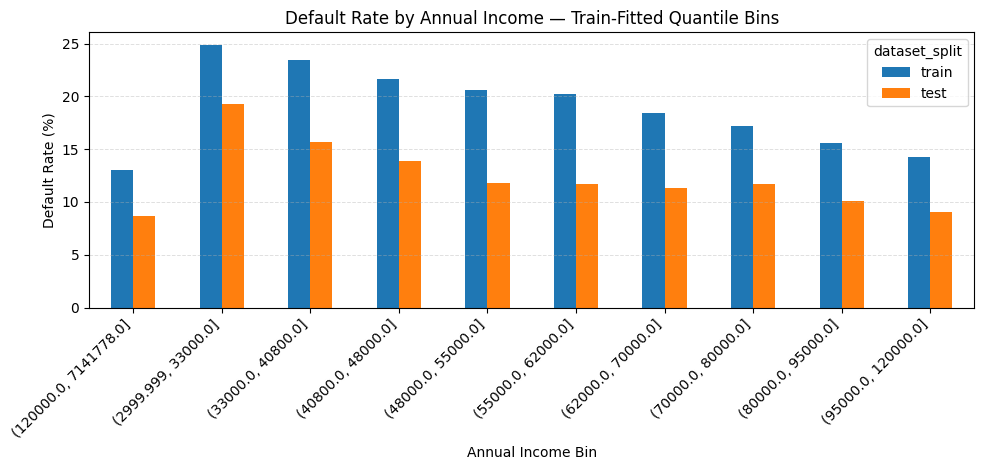

,feature_name,dataset_split,home_ownership,loan_count,default_rate_percent
0,home_ownership,train,mortgage,112371,17.04
1,home_ownership,train,other,185,18.38
2,home_ownership,train,own,19147,19.87
3,home_ownership,train,rent,96343,21.09
4,home_ownership,test,mortgage,12971,9.45
5,home_ownership,test,own,2948,11.19
6,home_ownership,test,rent,10225,15.69


In [15]:
# --------------------------------------------------------
# Application profile
# --------------------------------------------------------

application_numeric_columns = [
    "annual_inc",
    "emp_length_years",
]

eda_fig.plot_numeric_distribution_grid(
    df=df_feature_base_train_terminal,
    column_names=application_numeric_columns,
    title="Application Profile — Train Distributions",
    bins=40,
)

annual_income_summary_df = eda.build_numeric_feature_summary(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="annual_inc",
)

display(annual_income_summary_df)

annual_income_default_rate_df = eda.build_default_rate_by_train_fitted_quantile(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="annual_inc",
)

eda_fig.plot_default_rate_comparison(
    annual_income_default_rate_df,
    category_column="feature_bin",
    title="Default Rate by Annual Income — Train-Fitted Quantile Bins",
    xlabel="Annual Income Bin",
    rotate_labels=True,
)

home_ownership_default_rate_df = eda.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="home_ownership",
)

display(home_ownership_default_rate_df)

application_profile_tables_file = eda_tables_dir / "application_profile_tables.csv"
pd.concat(
    [
        annual_income_default_rate_df,
        home_ownership_default_rate_df.rename(columns={"home_ownership": "feature_bin"}),
    ],
    axis=0,
    ignore_index=True,
).to_csv(application_profile_tables_file, index=False)

log(f"[feature_base][application_profile] tables_file={application_profile_tables_file}")


### 2.3 Loan Structure

Loan-structure variables describe the requested contract rather than the borrower. The relevant question is whether contract design and stated use are associated with materially different default outcomes.


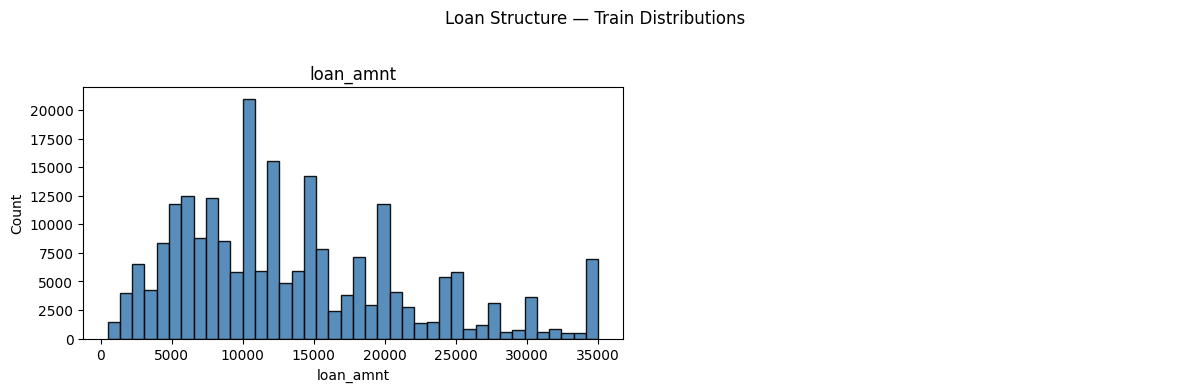

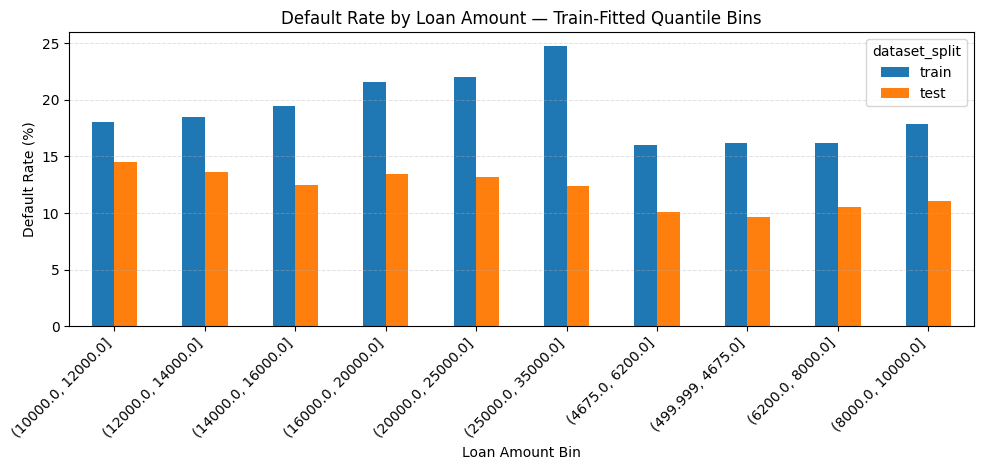

,feature_name,dataset_split,term_months,loan_count,default_rate_percent
0,term_months,train,36,179046,15.61
1,term_months,train,60,49000,31.35
2,term_months,test,36,18327,10.11
3,term_months,test,60,7817,16.72


,feature_name,dataset_split,purpose,loan_count,default_rate_percent
0,purpose,train,car,3396,12.66
1,purpose,train,credit_card,45710,16.50
2,purpose,train,debt_consolidation,132820,19.86
3,purpose,train,educational,325,17.23
4,purpose,train,home_improvement,13232,16.29
5,purpose,train,house,1455,18.76
6,purpose,train,major_purchase,5729,14.26
7,purpose,train,medical,2585,20.54
8,purpose,train,moving,1803,22.13
9,purpose,train,other,12879,21.87


In [16]:
# --------------------------------------------------------
# Loan structure
# --------------------------------------------------------

loan_structure_numeric_columns = [
    "loan_amnt",
]

eda_fig.plot_numeric_distribution_grid(
    df=df_feature_base_train_terminal,
    column_names=loan_structure_numeric_columns,
    title="Loan Structure — Train Distributions",
    bins=40,
)

loan_amount_default_rate_df = eda.build_default_rate_by_train_fitted_quantile(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="loan_amnt",
)

eda_fig.plot_default_rate_comparison(
    loan_amount_default_rate_df,
    category_column="feature_bin",
    title="Default Rate by Loan Amount — Train-Fitted Quantile Bins",
    xlabel="Loan Amount Bin",
    rotate_labels=True,
)

term_default_rate_df = eda.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="term_months",
)

purpose_default_rate_df = eda.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="purpose",
)

display(term_default_rate_df)
display(purpose_default_rate_df)

loan_structure_tables_file = eda_tables_dir / "loan_structure_tables.csv"
pd.concat(
    [
        loan_amount_default_rate_df,
        term_default_rate_df.rename(columns={"term_months": "feature_bin"}),
        purpose_default_rate_df.rename(columns={"purpose": "feature_bin"}),
    ],
    axis=0,
    ignore_index=True,
).to_csv(loan_structure_tables_file, index=False)

log(f"[feature_base][loan_structure] tables_file={loan_structure_tables_file}")


### 2.4 Debt Burden

Debt-burden variables measure how much financial load the borrower already carries at the moment of application. This is one of the most important sections of the notebook because it speaks directly to repayment capacity.


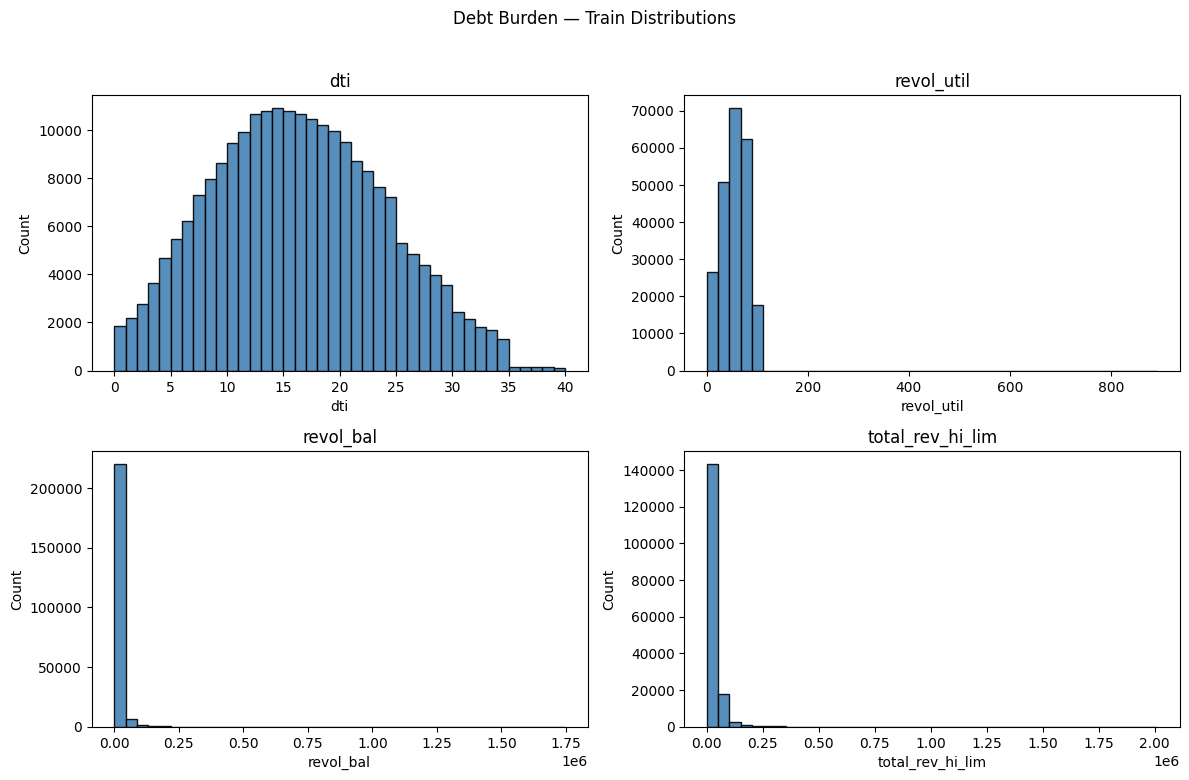

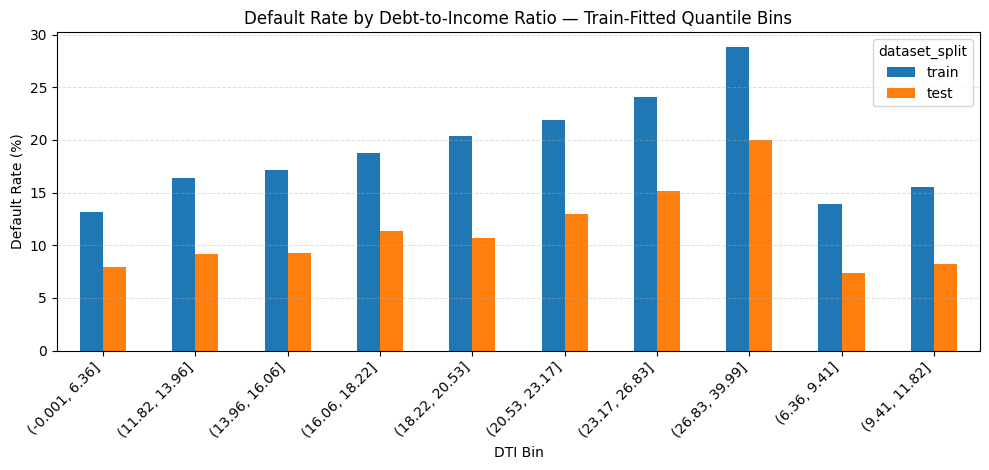

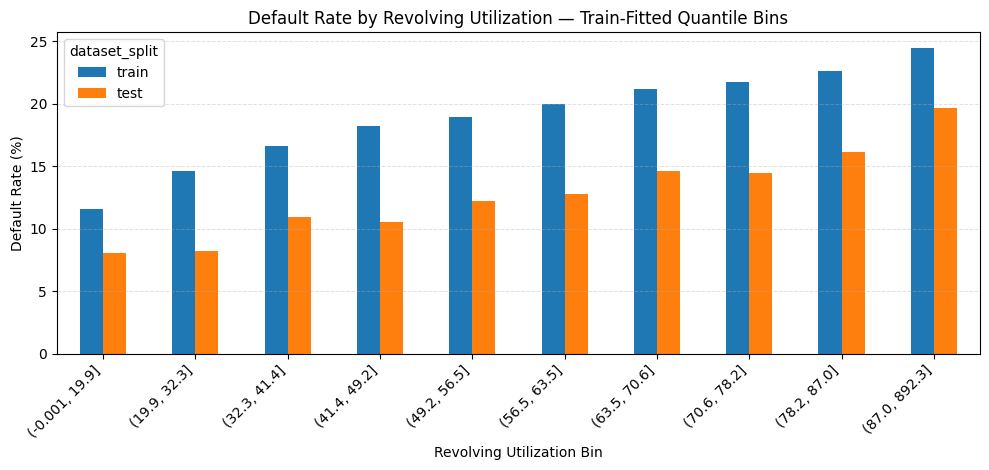

In [17]:
# --------------------------------------------------------
# Debt burden
# --------------------------------------------------------

debt_burden_numeric_columns = [
    "dti",
    "revol_util",
    "revol_bal",
    "total_rev_hi_lim",
]

eda_fig.plot_numeric_distribution_grid(
    df=df_feature_base_train_terminal,
    column_names=debt_burden_numeric_columns,
    title="Debt Burden — Train Distributions",
    bins=40,
)

dti_default_rate_df = eda.build_default_rate_by_train_fitted_quantile(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="dti",
)

eda_fig.plot_default_rate_comparison(
    dti_default_rate_df,
    category_column="feature_bin",
    title="Default Rate by Debt-to-Income Ratio — Train-Fitted Quantile Bins",
    xlabel="DTI Bin",
    rotate_labels=True,
)

revol_util_default_rate_df = eda.build_default_rate_by_train_fitted_quantile(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="revol_util",
)

eda_fig.plot_default_rate_comparison(
    revol_util_default_rate_df,
    category_column="feature_bin",
    title="Default Rate by Revolving Utilization — Train-Fitted Quantile Bins",
    xlabel="Revolving Utilization Bin",
    rotate_labels=True,
)

debt_burden_tables_file = eda_tables_dir / "debt_burden_tables.csv"
pd.concat(
    [dti_default_rate_df, revol_util_default_rate_df],
    axis=0,
    ignore_index=True,
).to_csv(debt_burden_tables_file, index=False)

log(f"[feature_base][debt_burden] tables_file={debt_burden_tables_file}")


### 2.5 Credit History

Credit-history variables summarize the depth and condition of the borrower’s credit file. The question is whether longer and cleaner histories are associated with lower realized default rates.


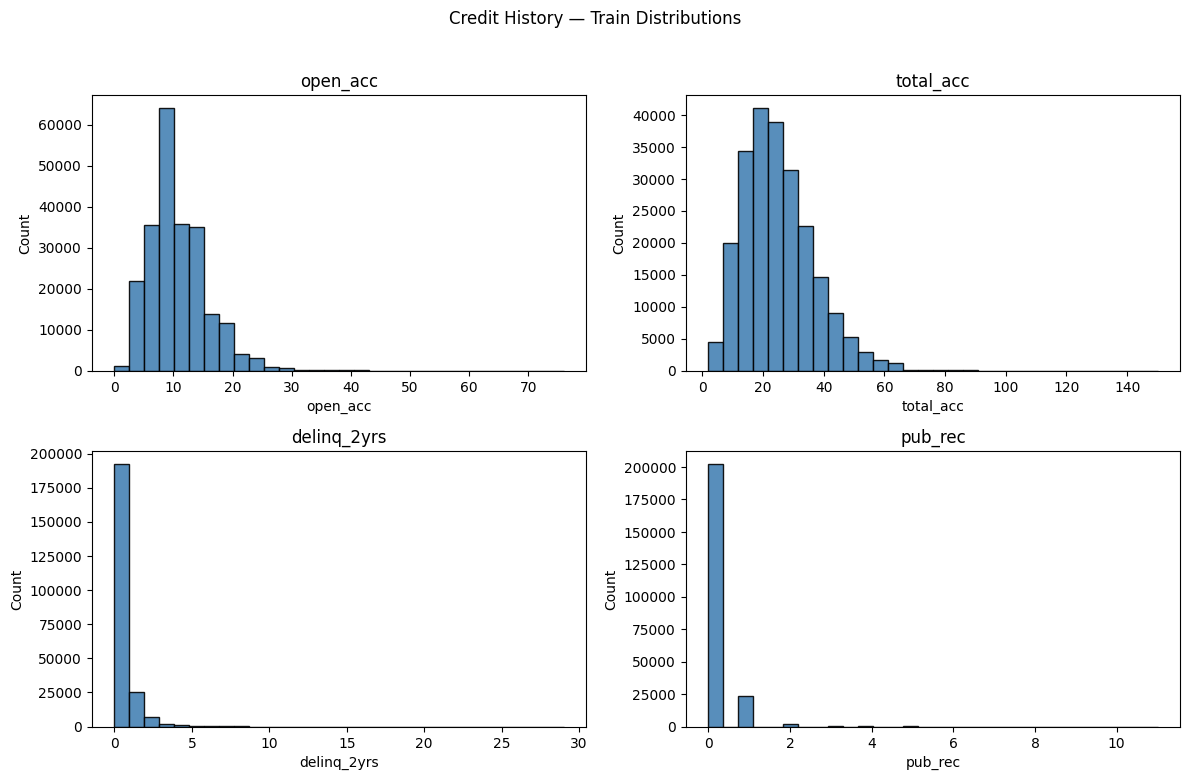

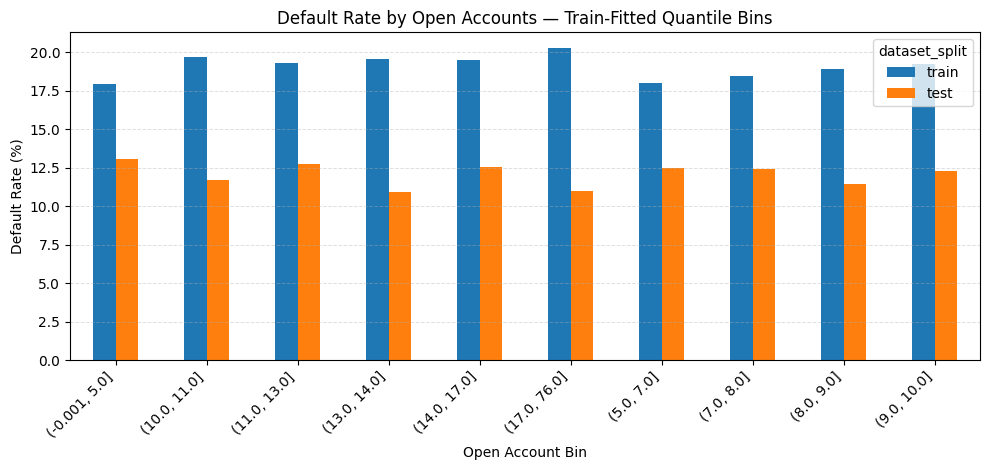

,feature_name,dataset_split,pub_rec,loan_count,default_rate_percent
0,pub_rec,train,0.0,201930,18.90
1,pub_rec,train,1.0,23284,19.49
2,pub_rec,train,10.0,5,0.00
3,pub_rec,train,11.0,1,0.00
4,pub_rec,train,2.0,1996,21.94
5,pub_rec,train,3.0,526,18.82
6,pub_rec,train,4.0,165,24.85
7,pub_rec,train,5.0,78,26.92
8,pub_rec,train,6.0,35,22.86
9,pub_rec,train,7.0,16,31.25


In [18]:
# --------------------------------------------------------
# Credit history
# --------------------------------------------------------

credit_history_numeric_columns = [
    "open_acc",
    "total_acc",
    "delinq_2yrs",
    "pub_rec",
]

eda_fig.plot_numeric_distribution_grid(
    df=df_feature_base_train_terminal,
    column_names=credit_history_numeric_columns,
    title="Credit History — Train Distributions",
    bins=30,
)

open_acc_default_rate_df = eda.build_default_rate_by_train_fitted_quantile(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="open_acc",
)

eda_fig.plot_default_rate_comparison(
    open_acc_default_rate_df,
    category_column="feature_bin",
    title="Default Rate by Open Accounts — Train-Fitted Quantile Bins",
    xlabel="Open Account Bin",
    rotate_labels=True,
)

pub_rec_default_rate_df = eda.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="pub_rec",
)

display(pub_rec_default_rate_df)

credit_history_tables_file = eda_tables_dir / "credit_history_tables.csv"
pd.concat(
    [
        open_acc_default_rate_df,
        pub_rec_default_rate_df.rename(columns={"pub_rec": "feature_bin"}),
    ],
    axis=0,
    ignore_index=True,
).to_csv(credit_history_tables_file, index=False)

log(f"[feature_base][credit_history] tables_file={credit_history_tables_file}")


### 2.6 Recent Credit Behavior

Recent-credit-behavior variables capture short-horizon credit activity and the recency of adverse events. The purpose here is to determine whether recent strain or recent credit seeking is associated with materially higher realized default risk.


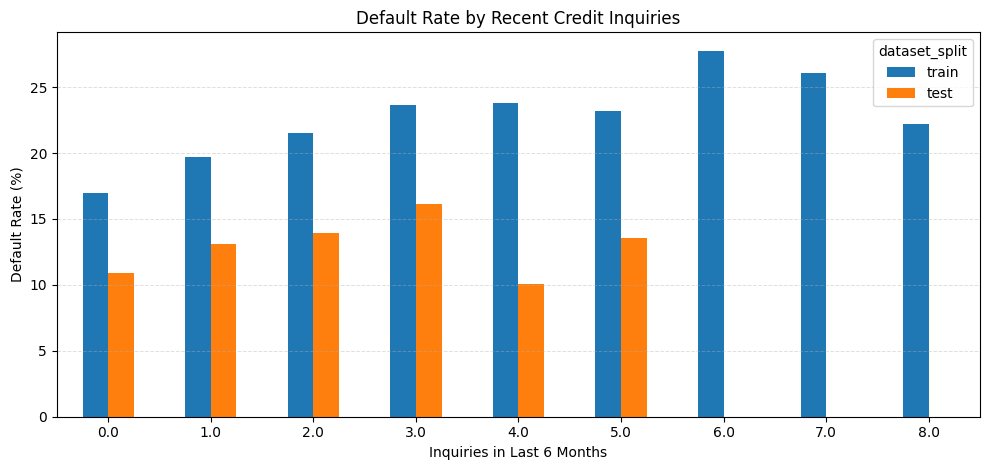

,feature_name,dataset_split,has_mths_since_last_delinq,loan_count,default_rate_percent
0,has_mths_since_last_delinq,train,0,128485,18.74
1,has_mths_since_last_delinq,train,1,99561,19.31
2,has_mths_since_last_delinq,test,0,12961,12.40
3,has_mths_since_last_delinq,test,1,13183,11.78


,feature_name,dataset_split,has_mths_since_last_major_derog,loan_count,default_rate_percent
0,has_mths_since_last_major_derog,train,0,187814,18.71
1,has_mths_since_last_major_derog,train,1,40232,20.30
2,has_mths_since_last_major_derog,test,0,18500,12.12
3,has_mths_since_last_major_derog,test,1,7644,12.01


,feature_name,dataset_split,has_mths_since_last_record,loan_count,default_rate_percent
0,has_mths_since_last_record,train,0,201260,18.90
1,has_mths_since_last_record,train,1,26786,19.64
2,has_mths_since_last_record,test,0,21116,12.19
3,has_mths_since_last_record,test,1,5028,11.63


In [19]:
# --------------------------------------------------------
# Recent credit behavior
# --------------------------------------------------------

inquiries_default_rate_df = eda.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="inq_last_6mths",
)

eda_fig.plot_default_rate_comparison(
    inquiries_default_rate_df,
    category_column="inq_last_6mths",
    title="Default Rate by Recent Credit Inquiries",
    xlabel="Inquiries in Last 6 Months",
)

last_delinq_flag_default_rate_df = eda.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="has_mths_since_last_delinq",
)

last_major_derog_flag_default_rate_df = eda.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="has_mths_since_last_major_derog",
)

last_record_flag_default_rate_df = eda.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="has_mths_since_last_record",
)

display(last_delinq_flag_default_rate_df)
display(last_major_derog_flag_default_rate_df)
display(last_record_flag_default_rate_df)

recent_credit_behavior_tables_file = eda_tables_dir / "recent_credit_behavior_tables.csv"
pd.concat(
    [
        inquiries_default_rate_df.rename(columns={"inq_last_6mths": "feature_bin"}),
        last_delinq_flag_default_rate_df.rename(columns={"has_mths_since_last_delinq": "feature_bin"}),
        last_major_derog_flag_default_rate_df.rename(columns={"has_mths_since_last_major_derog": "feature_bin"}),
        last_record_flag_default_rate_df.rename(columns={"has_mths_since_last_record": "feature_bin"}),
    ],
    axis=0,
    ignore_index=True,
).to_csv(recent_credit_behavior_tables_file, index=False)

log(f"[feature_base][recent_credit_behavior] tables_file={recent_credit_behavior_tables_file}")


### 2.7 Reporting Shifts / Data Quality

The reporting-shift-sensitive balance variables identified in the clean dataset remain relevant in the feature base dataset, but they are no longer evaluated over time because `issue_d` is not retained here. The relevant question is whether missingness differs materially between train and test and whether the explicit missingness flags carry risk information.


In [20]:
# --------------------------------------------------------
# Reporting shifts and data quality
# --------------------------------------------------------

feature_base_reporting_shift_columns = [
    "tot_coll_amt",
    "tot_cur_bal",
    "total_rev_hi_lim",
]

feature_base_missingness_summary_df = eda.build_feature_missingness_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    column_names=feature_base_reporting_shift_columns,
)

feature_base_missingness_summary_df["dataset_split"] = pd.Categorical(
    feature_base_missingness_summary_df["dataset_split"],
    categories=["train", "test"],
    ordered=True,
)

feature_base_missingness_summary_df = feature_base_missingness_summary_df.sort_values(
    ["dataset_split", "feature_name"]
).reset_index(drop=True)

display(feature_base_missingness_summary_df)

tot_cur_bal_missing_default_rate_df = eda.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="tot_cur_bal",
    treat_as_missingness=True,
)

total_rev_hi_lim_missing_default_rate_df = eda.build_default_rate_by_category_comparison(
    df_train=df_feature_base_train_terminal,
    df_test=df_feature_base_test_terminal,
    feature_name="total_rev_hi_lim",
    treat_as_missingness=True,
)

display(tot_cur_bal_missing_default_rate_df)
display(total_rev_hi_lim_missing_default_rate_df)

data_quality_tables_file = eda_tables_dir / "reporting_shift_data_quality_tables.csv"
pd.concat(
    [
        feature_base_missingness_summary_df.rename(columns={"feature_name": "feature_bin"}),
        tot_cur_bal_missing_default_rate_df.rename(columns={"tot_cur_bal_missing": "feature_bin"}),
        total_rev_hi_lim_missing_default_rate_df.rename(columns={"total_rev_hi_lim_missing": "feature_bin"}),
    ],
    axis=0,
    ignore_index=True,
).to_csv(data_quality_tables_file, index=False)

log(f"[feature_base][data_quality] tables_file={data_quality_tables_file}")


,feature_name,dataset_split,missing_percent
0,tot_coll_amt,train,27.94
1,tot_cur_bal,train,27.94
2,total_rev_hi_lim,train,27.94
3,tot_coll_amt,test,0.00
4,tot_cur_bal,test,0.00
5,total_rev_hi_lim,test,0.00


,feature_name,dataset_split,category,loan_count,default_rate_percent
0,tot_cur_bal,train,missing,63726,15.75
1,tot_cur_bal,train,not_missing,164320,20.25
2,tot_cur_bal,test,not_missing,26144,12.09


,feature_name,dataset_split,category,loan_count,default_rate_percent
0,total_rev_hi_lim,train,missing,63726,15.75
1,total_rev_hi_lim,train,not_missing,164320,20.25
2,total_rev_hi_lim,test,not_missing,26144,12.09


#### 2.8 Decision EDA Summary — Submission-Time Feature Behavior

The feature base analysis shows that the submission-time feature space contains interpretable risk structure without relying on post-origination information. Application profile, loan design, leverage, credit-file depth, recent credit activity, and explicit missingness all show patterns that are consistent with economically plausible differences in repayment risk.

The important point is not that every variable is equally strong. It is that the feature space contains multiple coherent channels through which default risk can be represented. That is sufficient to justify the modeling stage.


In [21]:
import inspect
import plots.eda_figures as eda_fig

print(eda_fig.__file__)
print(inspect.getsource(eda_fig.plot_numeric_distribution_grid))

D:\Portfolio\loans-at-risk-capturing-default\src\plots\eda_figures.py
def plot_numeric_distribution_grid(
    df: pd.DataFrame,
    *,
    column_names: Sequence[str],
    title: str,
    bins: int = 40,
    ncols: int = 2,
) -> None:
    """
    Plot histograms for a group of numeric variables.
    """
    if not column_names:
        raise ValueError("plot_numeric_distribution_grid: column_names must not be empty")

    number_of_columns = len(column_names)
    number_of_rows = ceil(number_of_columns / ncols)

    fig, axes = plt.subplots(
        number_of_rows,
        ncols,
        figsize=(6 * ncols, 3.8 * number_of_rows),
    )

    if hasattr(axes, "flatten"):
        axes_list = axes.flatten()
    else:
        axes_list = [axes]

    for axis, column_name in zip(axes_list, column_names):
        axis.hist(
            df[column_name].dropna(),
            bins=bins,
            color="steelblue",
            alpha=0.9,
            edgecolor="black",
            linewidth=1.0